In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [42]:
df=pd.read_csv('cleaned_data.csv')
df

,Unnamed: 0.1,Unnamed: 0,date,demand,RRP,demand_pos_RRP,RRP_positive,demand_neg_RRP,RRP_negative,frac_at_neg_RRP,min_temperature,max_temperature,solar_exposure,rainfall,school_day,holiday
0,0,0.0,2015-01-01,99635.030,25.633696,97319.240,26.415953,2315.790,-7.240000,0.020833,13.3,26.9,23.6,0.0,N,Y
1,1,1.0,2015-01-02,129606.010,33.138988,121082.015,38.837661,8523.995,-47.809777,0.062500,15.4,38.8,26.8,0.0,N,N
2,2,2.0,2015-01-03,142300.540,34.564855,142300.540,34.564855,0.000,0.000000,0.000000,20.0,38.2,26.5,0.0,N,N
3,3,3.0,2015-01-04,104330.715,25.005560,104330.715,25.005560,0.000,0.000000,0.000000,16.3,21.4,25.2,4.2,N,N
4,4,4.0,2015-01-05,118132.200,26.724176,118132.200,26.724176,0.000,0.000000,0.000000,15.0,22.0,30.7,0.0,N,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2101,2101,2101.0,2020-10-02,99585.835,-6.076028,41988.240,26.980251,57597.595,-30.173823,0.625000,12.8,26.0,22.0,0.0,N,N
2102,2102,2102.0,2020-10-03,92277.025,-1.983471,44133.510,32.438156,48143.515,-33.538025,0.583333,17.4,29.4,19.8,0.0,N,N
2103,2103,2103.0,2020-10-04,94081.565,25.008614,88580.995,26.571687,5500.570,-0.163066,0.062500,13.5,29.5,8.4,0.0,N,N
2104,2104,2104.0,2020-10-05,113610.030,36.764701,106587.375,39.616015,7022.655,-6.511550,0.083333,9.1,12.7,7.3,12.8,N,N


In [44]:
print("Missing values")
print(df[['date', 'demand',	'RRP', 'demand_pos_RRP', 'RRP_positive', 'demand_neg_RRP', 'RRP_negative', 'frac_at_neg_RRP', 'min_temperature', 'max_temperature', 'solar_exposure', 'rainfall', 'school_day', 'holiday']].isnull().sum())

Missing values
date               0
demand             0
RRP                0
demand_pos_RRP     0
RRP_positive       0
demand_neg_RRP     0
RRP_negative       0
frac_at_neg_RRP    0
min_temperature    0
max_temperature    0
solar_exposure     0
rainfall           0
school_day         0
holiday            0
dtype: int64


In [46]:
df.dtypes

Unnamed: 0.1         int64
Unnamed: 0         float64
date                object
demand             float64
RRP                float64
demand_pos_RRP     float64
RRP_positive       float64
demand_neg_RRP     float64
RRP_negative       float64
frac_at_neg_RRP    float64
min_temperature    float64
max_temperature    float64
solar_exposure     float64
rainfall           float64
school_day          object
holiday             object
dtype: object

In [48]:
from prophet import Prophet
from sklearn.preprocessing import OneHotEncoder

In [50]:
df=df.sort_values(by='date')
df.ffill(inplace=True)

In [52]:
df['date']=pd.to_datetime(df['date'])

In [54]:
print(df.columns.tolist()) 

['Unnamed: 0.1', 'Unnamed: 0', 'date', 'demand', 'RRP', 'demand_pos_RRP', 'RRP_positive', 'demand_neg_RRP', 'RRP_negative', 'frac_at_neg_RRP', 'min_temperature', 'max_temperature', 'solar_exposure', 'rainfall', 'school_day', 'holiday']


In [56]:
ohe_encoder=OneHotEncoder(drop='first',sparse_output=False).set_output(transform='pandas')
categorical=['school_day','holiday']
encoded_df=ohe_encoder.fit_transform(df[categorical])
df=pd.concat([df,encoded_df],axis=1).drop(columns=categorical)

In [58]:
df

,Unnamed: 0.1,Unnamed: 0,date,demand,RRP,demand_pos_RRP,RRP_positive,demand_neg_RRP,RRP_negative,frac_at_neg_RRP,min_temperature,max_temperature,solar_exposure,rainfall,school_day_Y,holiday_Y
0,0,0.0,2015-01-01,99635.030,25.633696,97319.240,26.415953,2315.790,-7.240000,0.020833,13.3,26.9,23.6,0.0,0.0,1.0
1,1,1.0,2015-01-02,129606.010,33.138988,121082.015,38.837661,8523.995,-47.809777,0.062500,15.4,38.8,26.8,0.0,0.0,0.0
2,2,2.0,2015-01-03,142300.540,34.564855,142300.540,34.564855,0.000,0.000000,0.000000,20.0,38.2,26.5,0.0,0.0,0.0
3,3,3.0,2015-01-04,104330.715,25.005560,104330.715,25.005560,0.000,0.000000,0.000000,16.3,21.4,25.2,4.2,0.0,0.0
4,4,4.0,2015-01-05,118132.200,26.724176,118132.200,26.724176,0.000,0.000000,0.000000,15.0,22.0,30.7,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2101,2101,2101.0,2020-10-02,99585.835,-6.076028,41988.240,26.980251,57597.595,-30.173823,0.625000,12.8,26.0,22.0,0.0,0.0,0.0
2102,2102,2102.0,2020-10-03,92277.025,-1.983471,44133.510,32.438156,48143.515,-33.538025,0.583333,17.4,29.4,19.8,0.0,0.0,0.0
2103,2103,2103.0,2020-10-04,94081.565,25.008614,88580.995,26.571687,5500.570,-0.163066,0.062500,13.5,29.5,8.4,0.0,0.0,0.0
2104,2104,2104.0,2020-10-05,113610.030,36.764701,106587.375,39.616015,7022.655,-6.511550,0.083333,9.1,12.7,7.3,12.8,0.0,0.0


In [60]:
df.to_csv("final_dataset.csv")

In [62]:
df = df.rename(columns={"date": "ds", "demand":"y"})
df=df[['ds', 'y',	'RRP', 'min_temperature', 'max_temperature', 'solar_exposure', 'rainfall', 'school_day_Y', 'holiday_Y']]

In [64]:
model=Prophet()
model.add_country_holidays(country_name="AU")
model.add_regressor('min_temperature')
model.add_regressor('max_temperature')
model.add_regressor('solar_exposure')
model.add_regressor('RRP')
model.add_regressor('school_day_Y')
model.add_regressor('holiday_Y')

In [66]:
model.fit(df)

17:11:44 - cmdstanpy - INFO - Chain [1] start processing
17:11:45 - cmdstanpy - INFO - Chain [1] done processing


In [68]:
future=model.make_future_dataframe(periods=30)
future["max_temperature"]=df["min_temperature"].iloc[-1]
future["min_temperature"]=df["max_temperature"].iloc[-1]
future["solar_exposure"]=df["solar_exposure"].iloc[-1]
future["RRP"]=df["RRP"].iloc[-1]
future["school_day_Y"]=df["school_day_Y"].iloc[-1]
future["holiday_Y"]=df["holiday_Y"].iloc[-1]

In [70]:
forecast=model.predict(future)

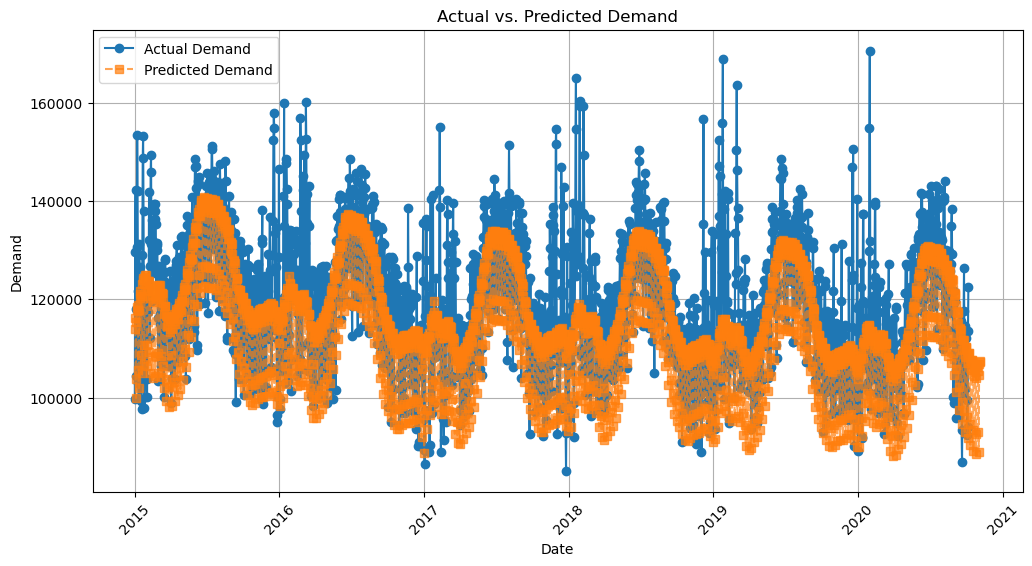

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot actual and predicted demand
plt.plot(df["ds"], df["y"], label="Actual Demand", marker='o', linestyle="-")
plt.plot(forecast["ds"], forecast["yhat"], label="Predicted Demand", marker='s', linestyle="--", alpha=0.7)

# Labels and title
plt.xlabel("Date")
plt.ylabel("Demand")
plt.title("Actual vs. Predicted Demand")

# Formatting
plt.legend()
plt.xticks(rotation=45)  # Rotating x-axis labels for better readability
plt.grid(True)

# Display the plot
plt.show()

In [74]:
df

,ds,y,RRP,min_temperature,max_temperature,solar_exposure,rainfall,school_day_Y,holiday_Y
0,2015-01-01,99635.030,25.633696,13.3,26.9,23.6,0.0,0.0,1.0
1,2015-01-02,129606.010,33.138988,15.4,38.8,26.8,0.0,0.0,0.0
2,2015-01-03,142300.540,34.564855,20.0,38.2,26.5,0.0,0.0,0.0
3,2015-01-04,104330.715,25.005560,16.3,21.4,25.2,4.2,0.0,0.0
4,2015-01-05,118132.200,26.724176,15.0,22.0,30.7,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
2101,2020-10-02,99585.835,-6.076028,12.8,26.0,22.0,0.0,0.0,0.0
2102,2020-10-03,92277.025,-1.983471,17.4,29.4,19.8,0.0,0.0,0.0
2103,2020-10-04,94081.565,25.008614,13.5,29.5,8.4,0.0,0.0,0.0
2104,2020-10-05,113610.030,36.764701,9.1,12.7,7.3,12.8,0.0,0.0


**FINDING SCORES(MAE,MSE,RMSE)**

**Without regressors**

In [77]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Ensure 'ds' column is in datetime format
df["ds"] = pd.to_datetime(df["ds"], errors="coerce")

# Train-Test Split: Use 80% of the data for training
train_size = int(0.8 * len(df))
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

# Initialize and fit Prophet model
model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model.fit(train_df)

# Create future dataframe for test period
future = test_df[['ds']]  # Using only existing dates from test set
forecast = model.predict(future)

# Extract actual and predicted values
y_true = test_df['y'].values
y_pred = forecast['yhat'].values  # Prophet's predicted values

# Calculate performance metrics
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)

# Print results
print(f"MAE (Mean Absolute Error): {mae:.4f}")
print(f"MSE (Mean Squared Error): {mse:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")


17:16:04 - cmdstanpy - INFO - Chain [1] start processing
17:16:04 - cmdstanpy - INFO - Chain [1] done processing


MAE (Mean Absolute Error): 6698.7757
MSE (Mean Squared Error): 77565783.2142
RMSE (Root Mean Squared Error): 8807.1439


**With regressors**

In [101]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Ensure 'ds' column is in datetime format
df["ds"] = pd.to_datetime(df["ds"], errors="coerce")

# Identify regressors (all columns except 'ds' and 'y')
regressors = [col for col in df.columns if col not in ["ds", "y"]]

# Train-Test Split: Use 80% of the data for training
train_size = int(0.8 * len(df))
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

# Initialize Prophet model
model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)

# Add regressors to Prophet model
for regressor in regressors:
    model.add_regressor(regressor)

# Fit the model
model.fit(train_df)

# Create future dataframe with test period and regressors
future = test_df[['ds'] + regressors]  # Ensure future df has ds and regressors

# Generate forecast
forecast = model.predict(future)

# Extract actual and predicted values
y_true = test_df['y'].values
y_pred = forecast['yhat'].values  # Prophet's predicted values

# Calculate performance metrics
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)

# Print results
print(f"MAE (Mean Absolute Error): {mae:.4f}")
print(f"MSE (Mean Squared Error): {mse:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")


17:36:42 - cmdstanpy - INFO - Chain [1] start processing
17:36:43 - cmdstanpy - INFO - Chain [1] done processing


MAE (Mean Absolute Error): 4.4817
MSE (Mean Squared Error): 31.4527
RMSE (Root Mean Squared Error): 5.6083


**Forecasting for one year**

18:10:03 - cmdstanpy - INFO - Chain [1] start processing
18:10:05 - cmdstanpy - INFO - Chain [1] done processing


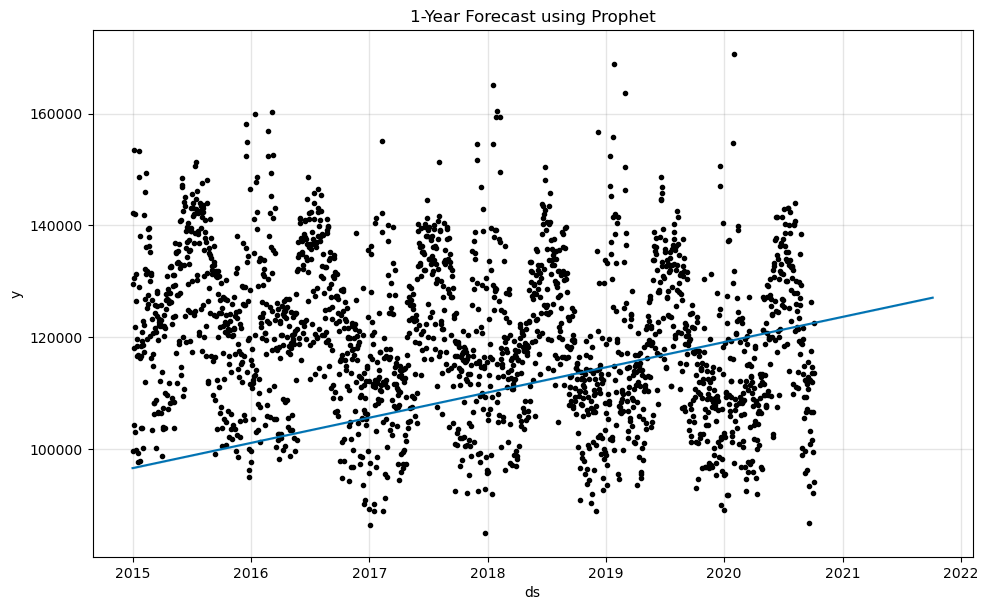

             ds           yhat     yhat_lower     yhat_upper
2106 2020-10-07  122620.119273  122581.366149  122658.447415
2107 2020-10-08  122632.454921  122595.418448  122670.404409
2108 2020-10-09  122644.765148  122608.081740  122682.274345
2109 2020-10-10  122656.960257  122617.873096  122694.005717
2110 2020-10-11  122669.183334  122630.138122  122705.861037
...         ...            ...            ...            ...
2466 2021-10-02  127059.691514  127018.411469  127098.446983
2467 2021-10-03  127071.943547  127033.841678  127109.579575
2468 2021-10-04  127084.505777  127047.381393  127125.267141
2469 2021-10-05  127096.862074  127056.164755  127134.614639
2470 2021-10-06  127109.212107  127070.970154  127147.384756

[365 rows x 4 columns]


In [110]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# Ensure 'ds' column is in datetime format
df["ds"] = pd.to_datetime(df["ds"], errors="coerce")

# Identify regressors (if any)
regressors = [col for col in df.columns if col not in ["ds", "y"]]

# Initialize Prophet model
model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)

# Add regressors if available
for regressor in regressors:
    model.add_regressor(regressor)

# Fit the model
model.fit(df)

# Create future dataframe for next 365 days
future = model.make_future_dataframe(periods=365)

# If regressors exist, fill them with last available values (assumption)
if regressors:
    last_values = df.iloc[-1][regressors]  # Get last row's values for regressors
    for regressor in regressors:
        future[regressor] = last_values[regressor]  # Fill future df with last known values

# Generate forecast
forecast = model.predict(future)

# Plot the forecast
fig = model.plot(forecast)
plt.title("1-Year Forecast using Prophet")
plt.show()

# Save forecast to CSV
forecast.to_csv("forecast_1_year.csv", index=False)

# Print first few forecasted values
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(365))


**Model training on prophet**

In [90]:
import pandas as pd

# Load dataset
df = pd.read_csv("final_dataset.csv")  # Replace with your actual file

# Convert 'Date' column to datetime format
df['date'] = pd.to_datetime(df['date'])

# Display the first few rows to verify the change
print(df.head())

# Optionally, save the modified DataFrame
df.to_csv("converted_file.csv", index=False)

   Unnamed: 0.2  Unnamed: 0.1  Unnamed: 0       date      demand        RRP  \
0             0             0         0.0 2015-01-01   99635.030  25.633696   
1             1             1         1.0 2015-01-02  129606.010  33.138988   
2             2             2         2.0 2015-01-03  142300.540  34.564855   
3             3             3         3.0 2015-01-04  104330.715  25.005560   
4             4             4         4.0 2015-01-05  118132.200  26.724176   

   demand_pos_RRP  RRP_positive  demand_neg_RRP  RRP_negative  \
0       97319.240     26.415953        2315.790     -7.240000   
1      121082.015     38.837661        8523.995    -47.809777   
2      142300.540     34.564855           0.000      0.000000   
3      104330.715     25.005560           0.000      0.000000   
4      118132.200     26.724176           0.000      0.000000   

   frac_at_neg_RRP  min_temperature  max_temperature  solar_exposure  \
0         0.020833             13.3             26.9          

In [92]:
!pip install prophet

In [94]:
import pandas as pd
from prophet import Prophet

# Load dataset
df = pd.read_csv("final_dataset.csv")  # Replace with your actual file

# Debug: Print actual column names to check what's available
print("Columns in dataset:", df.columns.tolist())

# Trim column names to remove leading/trailing spaces
df.columns = df.columns.str.strip().str.lower()  # Convert to lowercase for consistency

# Debug: Print column names after trimming
print("Columns after trimming:", df.columns.tolist())

# Identify correct columns dynamically
possible_date_cols = ["date", "ds", "timestamp"]
possible_value_cols = ["value", "y", "demand"]

date_col = next((col for col in possible_date_cols if col in df.columns), None)
value_col = next((col for col in possible_value_cols if col in df.columns), None)

# Ensure required columns exist
if date_col is None or value_col is None:
    raise KeyError(f"Could not find expected date or value columns. Found: {df.columns.tolist()}")

# Rename columns to 'ds' and 'y'
df.rename(columns={date_col: "ds", value_col: "y"}, inplace=True)

# Convert 'ds' column to datetime format
df["ds"] = pd.to_datetime(df["ds"], errors="coerce")

# Drop rows with missing values in 'ds' or 'y'
df.dropna(subset=["ds", "y"], inplace=True)

# Ensure 'y' column is numeric
df["y"] = pd.to_numeric(df["y"], errors="coerce")
df.dropna(subset=["y"], inplace=True)

# Check the first few rows
print(df.head())

# Initialize and fit Prophet model
model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model.fit(df)

# Create future dataframe
future = model.make_future_dataframe(periods=365)

# Predict
forecast = model.predict(future)

# Print forecasted data
print(forecast.head())

# Save the formatted dataset
df.to_csv("formatted_data.csv", index=False)


Columns in dataset: ['Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'date', 'demand', 'RRP', 'demand_pos_RRP', 'RRP_positive', 'demand_neg_RRP', 'RRP_negative', 'frac_at_neg_RRP', 'min_temperature', 'max_temperature', 'solar_exposure', 'rainfall', 'school_day_Y', 'holiday_Y']
Columns after trimming: ['unnamed: 0.2', 'unnamed: 0.1', 'unnamed: 0', 'date', 'demand', 'rrp', 'demand_pos_rrp', 'rrp_positive', 'demand_neg_rrp', 'rrp_negative', 'frac_at_neg_rrp', 'min_temperature', 'max_temperature', 'solar_exposure', 'rainfall', 'school_day_y', 'holiday_y']
   unnamed: 0.2  unnamed: 0.1  unnamed: 0         ds           y        rrp  \
0             0             0         0.0 2015-01-01   99635.030  25.633696   
1             1             1         1.0 2015-01-02  129606.010  33.138988   
2             2             2         2.0 2015-01-03  142300.540  34.564855   
3             3             3         3.0 2015-01-04  104330.715  25.005560   
4             4             4         4.0 2015-01

17:24:23 - cmdstanpy - INFO - Chain [1] start processing
17:24:24 - cmdstanpy - INFO - Chain [1] done processing


          ds          trend     yhat_lower     yhat_upper    trend_lower  \
0 2015-01-01  124563.138931  111585.571931  133524.196100  124563.138931   
1 2015-01-02  124563.215634  110082.305520  132193.643996  124563.215634   
2 2015-01-03  124563.292337   97439.649342  119191.539652  124563.292337   
3 2015-01-04  124563.369039   93283.662820  115802.226548  124563.369039   
4 2015-01-05  124563.445742  108334.759943  130801.047755  124563.445742   

     trend_upper  additive_terms  additive_terms_lower  additive_terms_upper  \
0  124563.138931    -1731.986534          -1731.986534          -1731.986534   
1  124563.215634    -3445.964083          -3445.964083          -3445.964083   
2  124563.292337   -16230.964254         -16230.964254         -16230.964254   
3  124563.369039   -19923.905729         -19923.905729         -19923.905729   
4  124563.445742    -4671.698005          -4671.698005          -4671.698005   

         weekly  weekly_lower  weekly_upper       yearly  year